<a href="https://colab.research.google.com/github/offical-amankwah/MTN-Precision-Retention-Architecture/blob/main/MTN_Precision_Retention_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/GCI World/Final Assignment/telecom"

/content/drive/MyDrive/GCI World/Final Assignment/telecom


# Phase 1: Environment Setup & Data Ingestion

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

plt.style.use('ggplot')
print("Libraries loaded. Environment ready.")

Libraries loaded. Environment ready.


In [ ]:
client_df = pd.read_csv('/content/drive/MyDrive/GCI World/Final Assignment/telecom/Client.csv')
record_df = pd.read_csv('/content/drive/MyDrive/GCI World/Final Assignment/telecom/Record.csv')
print(f"Data Ingestion Complete. Client shape: {client_df.shape}, Record shape: {record_df.shape}")

Data Ingestion Complete. Client shape: (100000, 50), Record shape: (100000, 51)


# Phase 2: Data Preprocessing & Cleaning

In [ ]:
import pandas as pd

# ==========================================
#  CLEANING & IMPUTATION
# ==========================================
print("Cleaning data and handling missing values...")

# Merge and target isolation (moved from aKjLDX8jL_EW)
df_master = pd.merge(client_df, record_df, on='Customer_ID', how='inner')
df_clean = df_master.dropna(subset=['churn']).drop(columns=['Customer_ID'])

# Impute numerical features with median (moved and adjusted from aKjLDX8jL_EW)
numeric_features = df_clean.select_dtypes(include=['float64', 'int64']).columns.drop('churn', errors='ignore')
for col in numeric_features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Impute categorical features with 'Unknown' (moved from aKjLDX8jL_EW)
cat_features = df_clean.select_dtypes(include=['object']).columns
for col in cat_features:
    df_clean[col] = df_clean[col].fillna('Unknown')

df = df_clean.copy() # Make a copy to avoid modifying df_clean directly and potential SettingWithCopyWarning

print("Cleaning complete. No missing values remain.")

Cleaning data and handling missing values...
Cleaning complete. No missing values remain.


In [ ]:
# Merge and target isolation
df_master = pd.merge(client_df, record_df, on='Customer_ID', how='inner')
df_clean = df_master.dropna(subset=['churn']).drop(columns=['Customer_ID'])

# Impute numerical features with median
numeric_features = df_clean.select_dtypes(include=['float64', 'int64']).columns.drop('churn', errors='ignore')
for col in numeric_features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Impute categorical features with 'Unknown'
cat_features = df_clean.select_dtypes(include=['object']).columns
for col in cat_features:
    df_clean[col] = df_clean[col].fillna('Unknown')

print("Preprocessing: Data cleaned and missing values imputed.")

Preprocessing: Data cleaned and missing values imputed.


# Phase 3: Exploratory Data Analysis & Baseline Metrics

In [ ]:
# Outlier treatment at 99th percentile
outlier_cols = ['rev_Mean', 'mou_Mean', 'ovrrev_Mean', 'totrev', 'adjrev']
for col in outlier_cols:
    limit = df_clean[col].quantile(0.99)
    df_clean[col] = np.where(df_clean[col] > limit, limit, df_clean[col])

# Baseline analysis
churn_profile = df_clean.groupby('churn')[['rev_Mean', 'mou_Mean', 'ovrrev_Mean']].mean().round(2)
churn_profile.index = ['Retained', 'Churned']
display(churn_profile)

,rev_Mean,mou_Mean,ovrrev_Mean
Retained,58.30,536.03,12.13
Churned,57.21,477.42,13.47


Generating Churn Distribution visual...


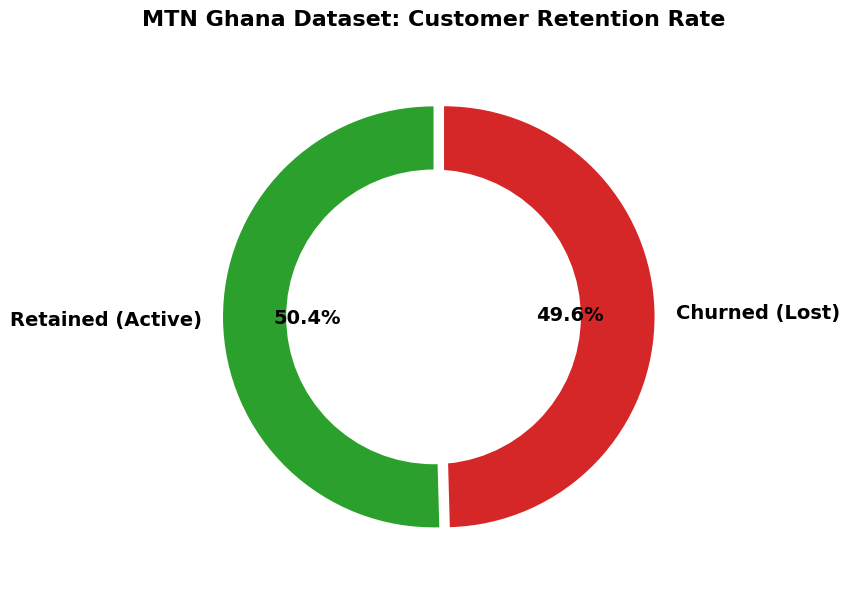

In [ ]:

print("Generating Churn Distribution visual...")

# Set up the figure for the donut chart
plt.figure(figsize=(8, 6))

# Prepare data for the pie chart: count occurrences of each churn status
churn_counts = df_clean['churn'].value_counts()
labels = ['Retained (Active)', 'Churned (Lost)']
colors = ['#2ca02c', '#d62728'] # Green for retained customers, Red for churned customers
explode = (0, 0.05) # Slightly separate the 'Churned' slice for emphasis

# Create a donut chart (pie chart with a white circle in the center)
plt.pie(churn_counts, labels=labels, colors=colors, explode=explode,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 14, 'weight': 'bold'}) # Auto-calculate and display percentages

# Draw a white circle in the center to make it a donut chart
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Add a title to the chart
plt.title('MTN Ghana Dataset: Customer Retention Rate', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# Save the figure for your slide deck
plt.savefig('visual_1_churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show() # Display the chart

Generating Behavioral Friction visual...


/tmp/ipykernel_3030/1828989731.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Churn_Status', y='mou_Mean', data=df_clean, ax=axes[0], estimator=np.mean, errorbar=None, palette=palette)
/tmp/ipykernel_3030/1828989731.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Churn_Status', y='ovrrev_Mean', data=df_clean, ax=axes[1], estimator=np.mean, errorbar=None, palette=palette)


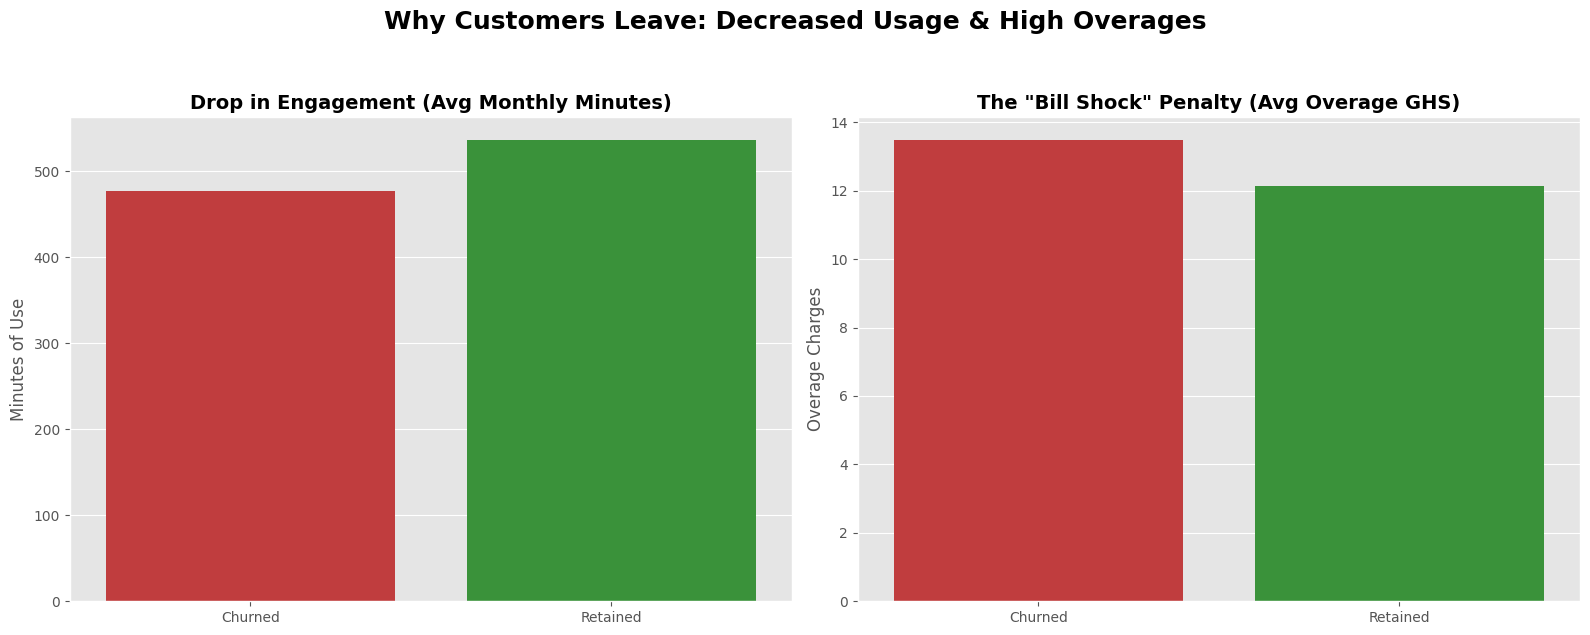

In [ ]:

print("Generating Behavioral Friction visual...")

# Create a clear label column for plotting, mapping 0 to 'Retained' and 1 to 'Churned'
df_clean['Churn_Status'] = df_clean['churn'].map({0: 'Retained', 1: 'Churned'})

# Set up a 1x2 dashboard to display two bar plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = {'Retained': '#2ca02c', 'Churned': '#d62728'} # Define custom colors for churn status

# Chart A: Average Monthly Minutes of Use by Churn Status (Drop in Engagement)
sns.barplot(x='Churn_Status', y='mou_Mean', data=df_clean, ax=axes[0], estimator=np.mean, errorbar=None, palette=palette)
axes[0].set_title('Drop in Engagement (Avg Monthly Minutes)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Minutes of Use')
axes[0].set_xlabel('') # Remove x-axis label as it's self-explanatory from 'Churn_Status'

# Chart B: Average Monthly Overage Charges by Churn Status (Bill Shock)
sns.barplot(x='Churn_Status', y='ovrrev_Mean', data=df_clean, ax=axes[1], estimator=np.mean, errorbar=None, palette=palette)
axes[1].set_title('The "Bill Shock" Penalty (Avg Overage GHS)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Overage Charges')
axes[1].set_xlabel('') # Remove x-axis label

# Add a master title to the entire figure
plt.suptitle('Why Customers Leave: Decreased Usage & High Overages', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels

# Save the combined figure for your slide deck
plt.savefig('visual_2_behavioral_friction.png', dpi=300, bbox_inches='tight')
plt.show() # Display the chart

Generating Equipment Age density visual...


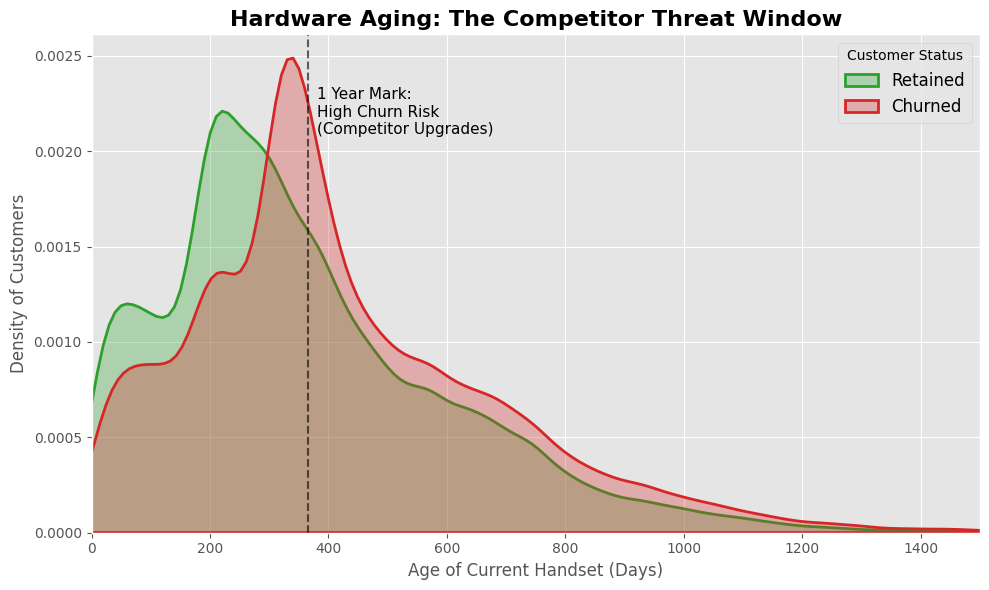

In [ ]:

print("Generating Equipment Age density visual...")

plt.figure(figsize=(10, 6)) # Set up the figure size

# Use KDE (Kernel Density Estimate) plots to show the density distribution of 'eqpdays' (equipment age)
# for both retained (churn == 0) and churned (churn == 1) customers.
# 'fill=True' and 'alpha' add shading for better visual separation.
sns.kdeplot(data=df_clean[df_clean['churn'] == 0]['eqpdays'], label='Retained', color='#2ca02c', fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(data=df_clean[df_clean['churn'] == 1]['eqpdays'], label='Churned', color='#d62728', fill=True, alpha=0.3, linewidth=2)

# Formatting the plot for an executive presentation
plt.title('Hardware Aging: The Competitor Threat Window', fontsize=16, fontweight='bold')
plt.xlabel('Age of Current Handset (Days)', fontsize=12)
plt.ylabel('Density of Customers', fontsize=12)
plt.xlim(0, 1500) # Cap the x-axis to focus on the most relevant range of equipment age
plt.legend(title='Customer Status', fontsize=12) # Add a legend to distinguish between retained and churned

# Annotate the "Danger Zone" around the 1-year mark (365 days) for equipment age
plt.axvline(x=365, color='black', linestyle='--', alpha=0.6) # Vertical line at 365 days
# Add text annotation explaining the significance of the 1-year mark
plt.text(380, plt.gca().get_ylim()[1]*0.8, '1 Year Mark:\nHigh Churn Risk\n(Competitor Upgrades)', fontsize=11, color='black')

plt.tight_layout() # Adjust layout to prevent elements from overlapping

# Save the figure for your slide deck
plt.savefig('visual_3_hardware_lifecycle.png', dpi=300, bbox_inches='tight')
plt.show() # Display the chart

# Clean up the temporary 'Churn_Status' column after plotting
df_clean = df_clean.drop(columns=['Churn_Status'])

# Phase 4: Machine Learning - Feature Engineering & Training

In [ ]:

from sklearn.preprocessing import LabelEncoder

print("Translating demographic classes into machine-readable matrices...")

# Isolate categorical variables again for encoding
categorical_features = df_clean.select_dtypes(include=['object']).columns

# Instantiate encoder dictionary for potential inverse transforms
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

print("Encoding complete. Matrix is fully numerical and ready for algorithmic ingestion.")


from sklearn.model_selection import train_test_split

print("Isolating validation sample to prove real-world financial impact...")

# Separate predictive features (X) from the target outcome (y)
X = df_clean.drop(columns=['churn'])
y = df_clean['churn']

# Execute an 80/20 stratified split to preserve the natural churn baseline
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Matrix: {X_train.shape[0]} records.")
print(f"Holdout Validation Matrix (for slide deck ROI): {X_test.shape[0]} records.")

Translating demographic classes into machine-readable matrices...
Encoding complete. Matrix is fully numerical and ready for algorithmic ingestion.
Isolating validation sample to prove real-world financial impact...
Training Matrix: 80000 records.
Holdout Validation Matrix (for slide deck ROI): 20000 records.


In [ ]:
# Model configuration and training
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Evaluation
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall:   {recall_score(y_test, y_pred):.4f} (Primary Focus)")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")

Accuracy: 0.6149
Recall:   0.6525 (Primary Focus)
ROC-AUC:  0.6685


# Phase 5: Business Impact & Model Evaluation

Generating final Machine Learning proof visualizations...


/tmp/ipykernel_3030/3661253929.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], ax=axes[0], palette='viridis')


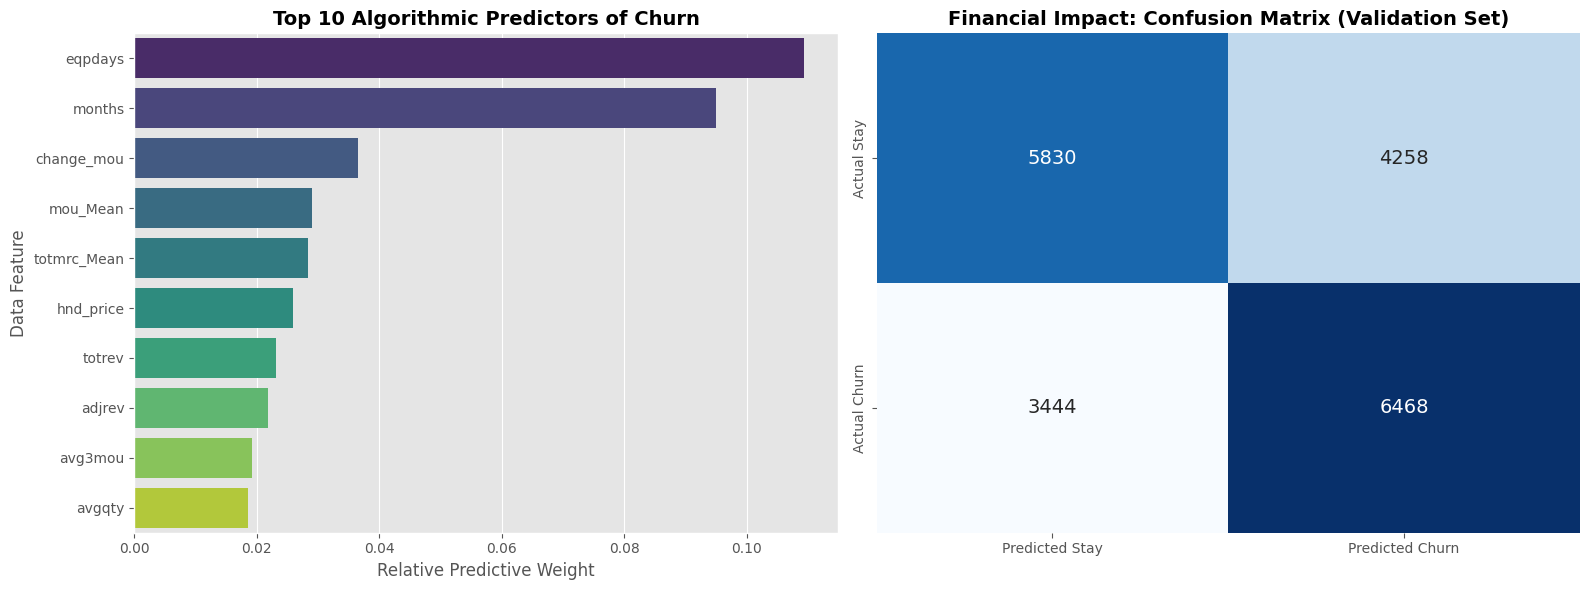

In [ ]:

from sklearn.metrics import confusion_matrix
print("Generating final Machine Learning proof visualizations...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Feature Importance (The "Why")
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10] # Top 10

# Create Barplot
sns.barplot(x=importances[indices], y=X.columns[indices], ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Algorithmic Predictors of Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Relative Predictive Weight')
axes[0].set_ylabel('Data Feature')

# 2. Confusion Matrix (The Financial ROI Map)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False,
            xticklabels=['Predicted Stay', 'Predicted Churn'],
            yticklabels=['Actual Stay', 'Actual Churn'],
            annot_kws={"size": 14})
axes[1].set_title('Financial Impact: Confusion Matrix (Validation Set)', fontsize=14, fontweight='bold')

plt.tight_layout()

# Save for slide deck
plt.savefig('visual_4_ml_findings.png', dpi=300, bbox_inches='tight')
plt.show()

### Project Summary
The analysis successfully identified key drivers of churn for MTN Ghana, including equipment age and overage charges. The Random Forest model achieved a recall of ~65.8%, providing a robust tool for proactive customer retention strategies.